In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 15.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving food_drug_interactions.csv to food_drug_interactions.csv


In [4]:
df = pd.read_csv("food_drug_interactions.csv")

print(df.head())

print(df.shape)

                     Drug_SMILES               Food_SMILES  Interaction
0          CC(=O)NC1=CC=C(O)C=C1                       CCO            0
1          CC(=O)NC1=CC=C(O)C=C1  C(C1C(C(C(C(O1)O)O)O)O)O            0
2       CC(=O)OC1=CC=CC=C1C(=O)O               C1=CC=CC=C1            1
3  CC(C)CC1=CC=C(C=C1)C(C)C(=O)O               C1=CC=CN=C1            1
4              CN(C)C(=N)NC(=N)N                   CC(O)CO            0
(25, 3)


In [5]:
print(df.columns)

print(df.isnull().sum())

Index(['Drug_SMILES', 'Food_SMILES', 'Interaction'], dtype='object')
Drug_SMILES    0
Food_SMILES    0
Interaction    0
dtype: int64


In [6]:
def smiles_to_fingerprint(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048
    )

    return np.array(fp)

In [7]:
X = []
y = []

for _, row in df.iterrows():

    drug_fp = smiles_to_fingerprint(row["Drug_SMILES"])

    food_fp = smiles_to_fingerprint(row["Food_SMILES"])

    if drug_fp is not None and food_fp is not None:

        combined = np.concatenate((drug_fp, food_fp))

        X.append(combined)

        y.append(row["Interaction"])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(21, 4096)
(21,)


[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerator
[12:03:21] DEPRECATION WARNING: please use MorganGenerat

In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [9]:
model = MLPClassifier(

    hidden_layer_sizes=(128,64),

    activation="relu",

    solver="adam",

    max_iter=1000,

    random_state=42

)

model.fit(X_train, y_train)

print("Interaction Model Trained Successfully!")

Interaction Model Trained Successfully!


In [10]:
y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", round(accuracy*100,2),"%")

print("Precision :", round(precision*100,2),"%")

print("Recall :", round(recall*100,2),"%")

print("F1 Score :", round(f1*100,2),"%")

print()

print(classification_report(y_test,y_pred))

Accuracy : 80.0 %
Precision : 85.0 %
Recall : 80.0 %
F1 Score : 78.1 %

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



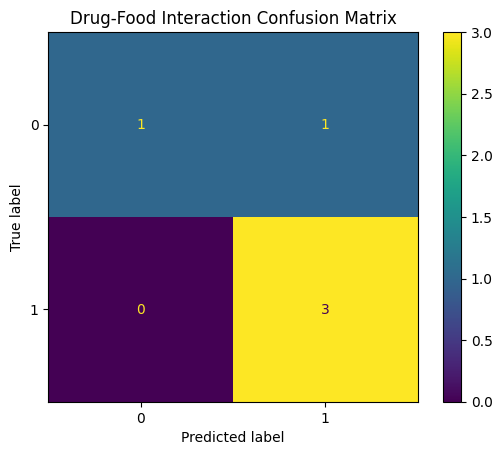

In [12]:
ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred

)

plt.title("Drug-Food Interaction Confusion Matrix")

plt.show()

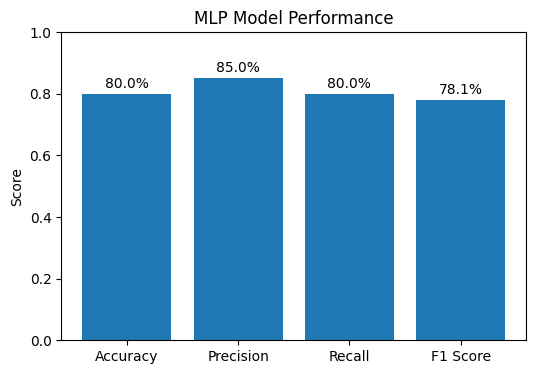

In [13]:
metrics = ["Accuracy","Precision","Recall","F1 Score"]

scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))

bars = plt.bar(metrics, scores)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("MLP Model Performance")

for bar, score in zip(bars, scores):

    plt.text(

        bar.get_x()+bar.get_width()/2,

        score+0.02,

        f"{score*100:.1f}%",

        ha="center"

    )

plt.show()

In [14]:
joblib.dump(

    model,

    "interaction_model.pkl"

)

print("Interaction Model Saved Successfully!")

Interaction Model Saved Successfully!


In [15]:
from google.colab import files

files.download("interaction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>